In [9]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
!pip install tensorflow opencv-python scikit-learn

In [30]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam



In [39]:
train_dir = '/content/drive/MyDrive/Pneumonia-Detection/data/chest_xray/train'
# val_dir = '/content/drive/MyDrive/Pneumonia-Detection/data/chest_xray/val'
test_dir = '/content/drive/MyDrive/Pneumonia-Detection/data/chest_xray/test'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    color_mode='rgb',
    subset='training',       # 👈 this is the 90%
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    color_mode='rgb',
    subset='validation',     # 👈 this is the 10%
    shuffle=False
)

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    color_mode='rgb',
    shuffle=False
)

classes = np.array([0, 1])
weights = compute_class_weight('balanced', classes=classes, y=train_generator.classes)
class_weights = dict(zip(classes, weights))
print(class_weights)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
{np.int64(0): np.float64(1.9445479962721341), np.int64(1): np.float64(0.6730645161290323)}


In [40]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = True

for layer in base_model.layers[:100]:
    layer.trainable = False
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,244,097 (92.48 MB)

 Trainable params: 20,109,313 (76.71 MB)

 Non-trainable params: 4,134,784 (15.77 MB)

In [41]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.5853 - loss: 0.6613 - val_accuracy: 0.7430 - val_loss: 0.6492
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 123s 940ms/step - accuracy: 0.8416 - loss: 0.3817 - val_accuracy: 0.7430 - val_loss: 0.5863
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 122s 932ms/step - accuracy: 0.8552 - loss: 0.3260 - val_accuracy: 0.7450 - val_loss: 0.8475
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 121s 926ms/step - accuracy: 0.8782 - loss: 0.2940 - val_accuracy: 0.8188 - val_loss: 0.3958
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 122s 931ms/step - accuracy: 0.8857 - loss: 0.2741 - val_accuracy: 0.8188 - val_loss: 0.3904
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 123s 942ms/step - accuracy: 0.8869 - loss: 0.2619 - val_accuracy: 0.8936 - val_loss: 0.2509
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 121s 927ms/step - accuracy: 0.8892 - loss: 0.2508 - val_accuracy: 0.4257 - val_loss: 1.6790
Epoch 8/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 121s 925ms/step - accuracy: 0.8837 - lo

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 328ms/step - accuracy: 0.8197 - loss: 0.6739
Test Accuracy: 0.8669871687889099
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 544ms/step


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Pneumonia-Detection/images/confusion_matrix.png'

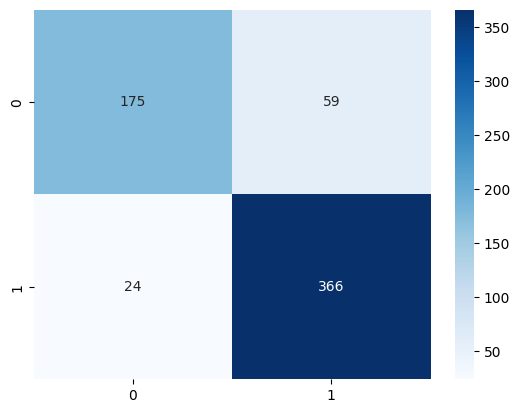

In [44]:
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test Accuracy: {test_acc}')

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = (model.predict(test_generator) > 0.5).astype(int)
y_true = test_generator.classes[:len(y_pred)]

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
plt.savefig('/content/drive/MyDrive/Pneumonia-Detection/images/confusion_matrix.png')
plt.show()

print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 347ms/step - accuracy: 0.8197 - loss: 0.6739
Test Accuracy: 0.8669871687889099
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 304ms/step
              precision    recall  f1-score   support

      Normal       0.88      0.75      0.81       234
   Pneumonia       0.86      0.94      0.90       390

    accuracy                           0.87       624
   macro avg       0.87      0.84      0.85       624
weighted avg       0.87      0.87      0.86       624



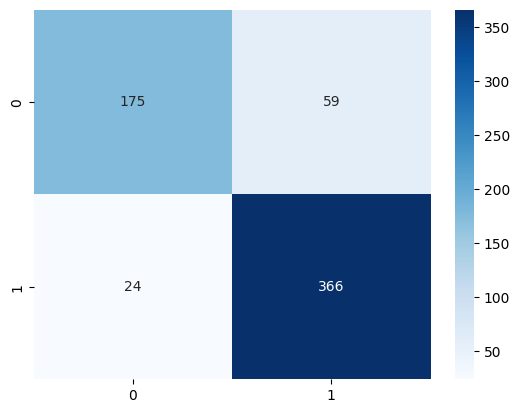

In [47]:
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test Accuracy: {test_acc}')

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = (model.predict(test_generator) > 0.5).astype(int)
y_true = test_generator.classes[:len(y_pred)]

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')

print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

In [51]:
model.save("pneumonia_model.keras")
print("Model saved in native Keras format")



Model saved in native Keras format


In [52]:
model.save("pneumonia_model.h5")
print("Model saved in HDF5 format")

Model saved in HDF5 format


In [53]:
model.save("/content/drive/MyDrive/Pneumonia-Detection/pneumonia_model.keras")
print("Model saved to Google Drive")

Model saved to Google Drive


In [55]:
os.makedirs('/content/drive/MyDrive/Pneumonia-Detection/images', exist_ok=True)

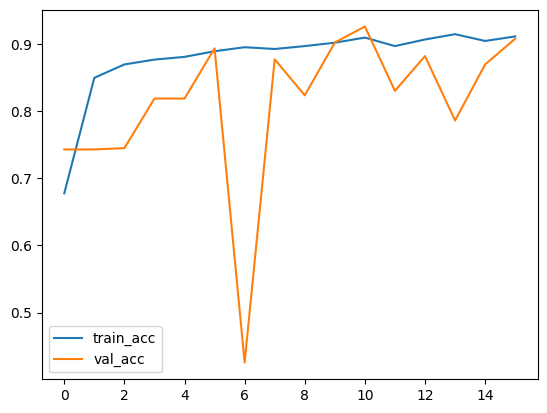

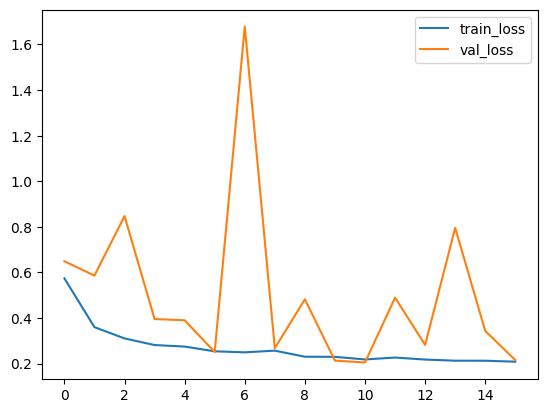

In [56]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.savefig('/content/drive/MyDrive/Pneumonia-Detection/images/accuracy_plot.png')
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.savefig('/content/drive/MyDrive/Pneumonia-Detection/images/loss_plot.png')
plt.show()
